# Unit End Project 5

# Career Simulation Projects


In [19]:
# install missing python libraries
%pip install nltk scikit-learn numpy pandas matplotlib tensorflow keras --quiet

Note: you may need to restart the kernel to use updated packages.


In [20]:
# imports
import os
import nltk
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from keras import layers, Model
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import AdamW, Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.losses import CategoricalFocalCrossentropy

# Set KERAS_BACKEND to TensorFlow
os.environ['KERAS_BACKEND'] = 'tensorflow'

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\simsk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\simsk\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [21]:
# Load complaints dataset into a pandas DataFrame
complaints_df = pd.read_csv('../data/complaints_banking_2023.csv')

# Look for null values in the dataset
print(complaints_df.isnull().sum())

# While not practical in all cases, we cannot run sentiment analysis on rows with a missing customer complaint, so those rows will be dropped.
no_null_complaints_df = complaints_df.dropna(subset=['Complaint Description'])
print(no_null_complaints_df.isnull().sum())

Complaint ID             1329
Date Received            1334
Banking Product          1325
Department               1335
Issue ID                 1331
Complaint Description    1330
State                    1359
ZIP                      1348
Bank Response            1329
dtype: int64
Complaint ID             1074
Date Received            1087
Banking Product          1078
Department               1097
Issue ID                 1092
Complaint Description       0
State                    1093
ZIP                      1097
Bank Response            1089
dtype: int64


In [22]:
# Load the dept and convert it into a list of dictionaries to help fill out data in the main complaints dataset
# The Product col should be the key and the Department col should be the value in the dictionary
dept_df = pd.read_csv('../data/Department_of_Product.csv')
dept_dict = dict(zip(dept_df['Product'], dept_df['Department']))
print(dept_dict)

# Fill out the missing values in the Department column of the complaints dataset by seeing if a the row has a Product value that matches a key in the dept_dict. 
# If a match is found, the corresponding Department value from the dept_dict will be used to fill the missing value. Then print the row the update was made to
dept_filled_complaints_df = no_null_complaints_df.copy()
for index, row in no_null_complaints_df.iterrows():
    if pd.isnull(row['Department']):
        product = row['Banking Product']
        if product in dept_dict:
            dept_filled_complaints_df.at[index, 'Department'] = dept_dict[product]
            print(dept_filled_complaints_df.loc[index])

print(dept_filled_complaints_df.isnull().sum())
# Since a department serves different banking products the reverse cannot be applied

{'Checking or savings account': 'CASA', 'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reports', 'Credit card or prepaid card': 'Credit Cards', 'Debt collection': 'Loans', 'Money transfer, virtual currency, or money service': 'Remittance', 'Mortgage': 'Mortgage', 'Vehicle loan or lease': 'Loans', 'Payday loan, title loan, or personal loan': 'Loans', 'Student loan': 'Loans', 'Credit Card': 'Credit Cards', 'Credit Reporting': 'Credit Reports', 'Payday loan': 'Loans', 'Bank Account or Service': 'Others', 'Money transfers': 'Remittance', 'Prepaid Card': 'Credit Cards', 'Consumer Loan': 'Loans', 'Other financial service': 'Others'}
Complaint ID                                                   CID65522280
Date Received                                                          NaN
Banking Product                                Checking or savings account
Department                                                            CASA
Issue ID                

In [23]:
# From the assignment, this function should:
# 1. Convert text to lowercase
# 2. Handle numbers
# 3. Handle stop words
# 4. Handle punctuation
# 5. Apply lemmatization
# I am also adding space condensation and normalizing whitespace
# Python does this automatically with split(), but adding it at the end of the function will ensure
# that any extra spaces created are condensed even if I add more later on and forget to handle it.
# 6. Normalize whitespace and condense multiple spaces into one space

test_text = """I Contacted Seller by email XX/XX/XXXX, XXXX pm, received email from XXXX, for XXXX # XXXX, confirming order.
            Ant chged to my XXXX was {$32.00} USD I clicked on View your Order and was given the Shipper and Tracking number : Shipper : XXXX ; Tracking number : XXXX.
            When I clicked on the tracking number, it had not been sent yet.
            I looked up this XXXX  through XXXX, and found XXXX, XXXX XXXX XXXX XXXX, XXXX XXXX, CA XXXX.
            ( This address, according to USPS records and XXXX, is just a house/residence, in XXXX XXXX XXXX California ) ).
            This address is a rental propertyin XXXX XXXX???"""

def preprocessing_pipeline(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Handle stop words:
    stop_words = set(stopwords.words('english'))
    text = ' '.join(word for word in text.split() if word not in stop_words)
    
    # Remove punctuation and special characters
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    
    # Handle numbers: convert all numbers to a special token (e.g., <NUM>)
    text = ''.join('<NUM>' if char.isdigit() else char for char in text)
    
    # Apply lemmatization
    lemmatizer = WordNetLemmatizer()
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split())
    
    # Normalize whitespace and condense multiple spaces into one space
    text = ' '.join(text.split())
    
    return text

# Print out our test text after processing to see the changes
print(preprocessing_pipeline(test_text))

contacted seller email xxxxxxxx xxxx pm received email xxxx xxxx xxxx confirming order ant chged xxxx <NUM><NUM><NUM><NUM> usd clicked view order given shipper tracking number shipper xxxx tracking number xxxx clicked tracking number sent yet looked xxxx xxxx found xxxx xxxx xxxx xxxx xxxx xxxx xxxx ca xxxx address according usps record xxxx houseresidence xxxx xxxx xxxx california address rental propertyin xxxx xxxx


In [24]:
# Preprocess the complaint descriptions in the dataset using the preprocessing_pipeline function and put into a new df overwriting the original complaint description column.
processed_complaints_df = dept_filled_complaints_df.copy()
processed_complaints_df['Complaint Description'] = processed_complaints_df['Complaint Description'].apply(preprocessing_pipeline)
print(processed_complaints_df['Complaint Description'].head())

# Save the preprocessed complaints dataset to a new CSV file
processed_complaints_df.to_csv('processed_complaints_banking_2023.csv', index=False)


0    xxxxxx<NUM><NUM> opened safe balance account o...
1    item bank abc credit report belong must remove...
2    xxxxxx<NUM><NUM> found account frozen apparent...
5    so last time phone b prepaid regarding edd acc...
6    got <NUM> hard inquiry dont recognize xxxx xxx...
Name: Complaint Description, dtype: str


### Start from here if the previous steps were completed in earlier runs:

In [25]:
# Load the preprocessed complaints dataset
processed_complaints_df = pd.read_csv('processed_complaints_banking_2023.csv')

In [26]:
# Vectorize the complaint descriptions using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_complaints_df['Complaint Description'])
print(processed_complaints_df.shape)
print(tfidf_matrix.shape)
print(tfidf_matrix)

(5681, 9)
(5681, 14795)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 375661 stored elements and shape (5681, 14795)>
  Coords	Values
  (0, 14692)	0.10242331489249618
  (0, 8728)	0.6681758863721883
  (0, 8964)	0.038069322396370626
  (0, 11394)	0.07107992525733131
  (0, 1228)	0.14029600616978544
  (0, 148)	0.08954922836901177
  (0, 8934)	0.0401156964447266
  (0, 13901)	0.04317956661539096
  (0, 9363)	0.07464927934001077
  (0, 2159)	0.06881617621157608
  (0, 8969)	0.10814352481356823
  (0, 1038)	0.1000199071043535
  (0, 7624)	0.14390718936252553
  (0, 780)	0.053918573524040475
  (0, 10448)	0.05075563279237753
  (0, 7610)	0.06137749857362628
  (0, 2828)	0.03808761232486168
  (0, 3233)	0.034681105272678085
  (0, 11693)	0.03382832385567838
  (0, 14562)	0.028765887357314716
  (0, 4595)	0.09314299723896514
  (0, 8006)	0.09412314062719557
  (0, 9581)	0.0953867483574673
  (0, 1824)	0.028960160797419233
  (0, 13166)	0.15706254682143977
  :	:
  (5680, 6703)	0.25773952556173474
  (

In [27]:
# Separate the target variable (Department) from the features (Complaint Descriptions)
X = tfidf_matrix
# Text labels need to be converted to numerical values for the model
y = to_categorical(processed_complaints_df['Department'].factorize()[0])
# Remove any rows from X and y by index using the original dataframe in which the Department value is null
# These can be saved for validation on later
null_dept_indices = processed_complaints_df[processed_complaints_df['Department'].isnull()].index
X_base = X[~processed_complaints_df.index.isin(null_dept_indices)]
y_base = y[~processed_complaints_df.index.isin(null_dept_indices)]
X_val = X[processed_complaints_df.index.isin(null_dept_indices)]
y_val = y[processed_complaints_df.index.isin(null_dept_indices)]
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_base, y_base, test_size=0.1, random_state=691)


In [28]:
# Define the neural network model
loss_fn = CategoricalFocalCrossentropy(alpha=0.2, gamma=2.0)
def create_model(input_dim, output_dim):
    input_layer = layers.Input(shape=(input_dim,))
    hidden_layer_1 = layers.Dense(64, activation='relu')(input_layer)
    hidden_layer_1 = layers.Dropout(0.5)(hidden_layer_1)
    hidden_layer_2 = layers.Dense(128, activation='relu')(hidden_layer_1)
    hidden_layer_2 = layers.Dropout(0.5)(hidden_layer_2)
    hidden_layer_3 = layers.Dense(256, activation='relu')(hidden_layer_2)
    hidden_layer_3 = layers.Dropout(0.5)(hidden_layer_3)
    hidden_layer_4 = layers.Dense(256, activation='relu')(hidden_layer_3)
    hidden_layer_4 = layers.Dropout(0.5)(hidden_layer_4)
    hidden_layer_5 = layers.Dense(128, activation='relu')(hidden_layer_4)
    hidden_layer_5 = layers.Dropout(0.5)(hidden_layer_5)
    # softmax, in general, is the better output activation func for multi-class classification problems
    output_layer = layers.Dense(output_dim, activation='softmax')(hidden_layer_5)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=AdamW(learning_rate=1e-5), loss=loss_fn, metrics=['accuracy', 'Precision', 'Recall'])
    return model

In [29]:
# Make a class weights dictionary for the imbalanced dataset to help the model learn better
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(processed_complaints_df['Department'].factorize()[0]), y=processed_complaints_df['Department'].factorize()[0])
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)
class_weights_dict[5] = class_weights_dict[5] + 1
class_weights_dict[7] = class_weights_dict[7] + 1
print(class_weights_dict)

{0: np.float64(1.8492838541666667), 1: np.float64(0.5530568535825545), 2: np.float64(0.888767209011264), 3: np.float64(0.5977483164983165), 4: np.float64(0.8115714285714286), 5: np.float64(2.165015243902439), 6: np.float64(1.063061377245509), 7: np.float64(4.5814516129032254)}
{0: np.float64(1.8492838541666667), 1: np.float64(0.5530568535825545), 2: np.float64(0.888767209011264), 3: np.float64(0.5977483164983165), 4: np.float64(0.8115714285714286), 5: np.float64(3.165015243902439), 6: np.float64(1.063061377245509), 7: np.float64(5.5814516129032254)}


In [30]:
# Create a keras model for classification using functional API
model = create_model(input_dim=X_train.shape[1], output_dim=y_train.shape[1])
model.summary()

# Train the model with early stopping callback to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor='val_Recall', patience=50, restore_best_weights=True, verbose=1, start_from_epoch=30)
# model.fit(X_train, y_train, epochs=1000, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping], class_weight=class_weights_dict)
model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])
# Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}', f'Precision: {precision:.4f}', f'Recall: {recall:.4f}')


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 14795)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       946,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,879 (4.15 MB)

 Trainable params: 1,087,879 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.1569 - loss: 0.2858 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2491 - val_loss: 0.2852
Epoch 2/1000
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.1928 - loss: 0.2850 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2491 - val_loss: 0.2845
Epoch 3/1000
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.2138 - loss: 0.2841 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2491 - val_loss: 0.2836
Epoch 4/1000
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.2196 - loss: 0.2830 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2491 - val_loss: 0.2825
Epoch 5/1000
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0000e+00 - Recall:

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


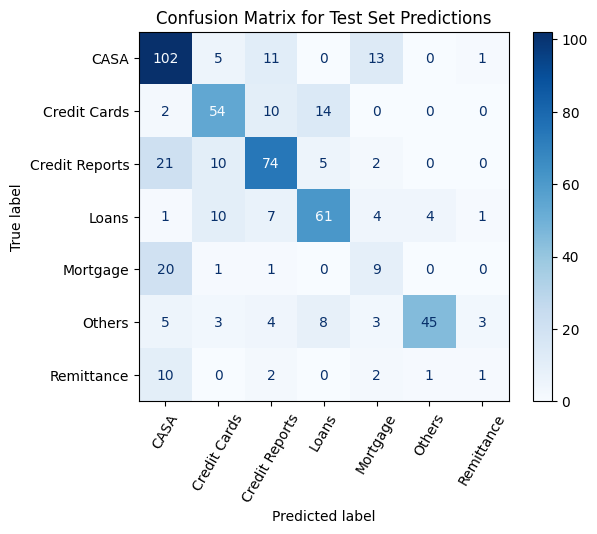

In [31]:
# Plot confusion matrix for test set predictions
# Use the non-categorical classes for the labels in the confusion matrix.
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(processed_complaints_df['Department'].dropna()))
disp.plot(cmap=plt.cm.Blues)
# Make the pips of the x-axis 60 degrees to make them easier to read
plt.xticks(rotation=60)
plt.title('Confusion Matrix for Test Set Predictions')
plt.show()

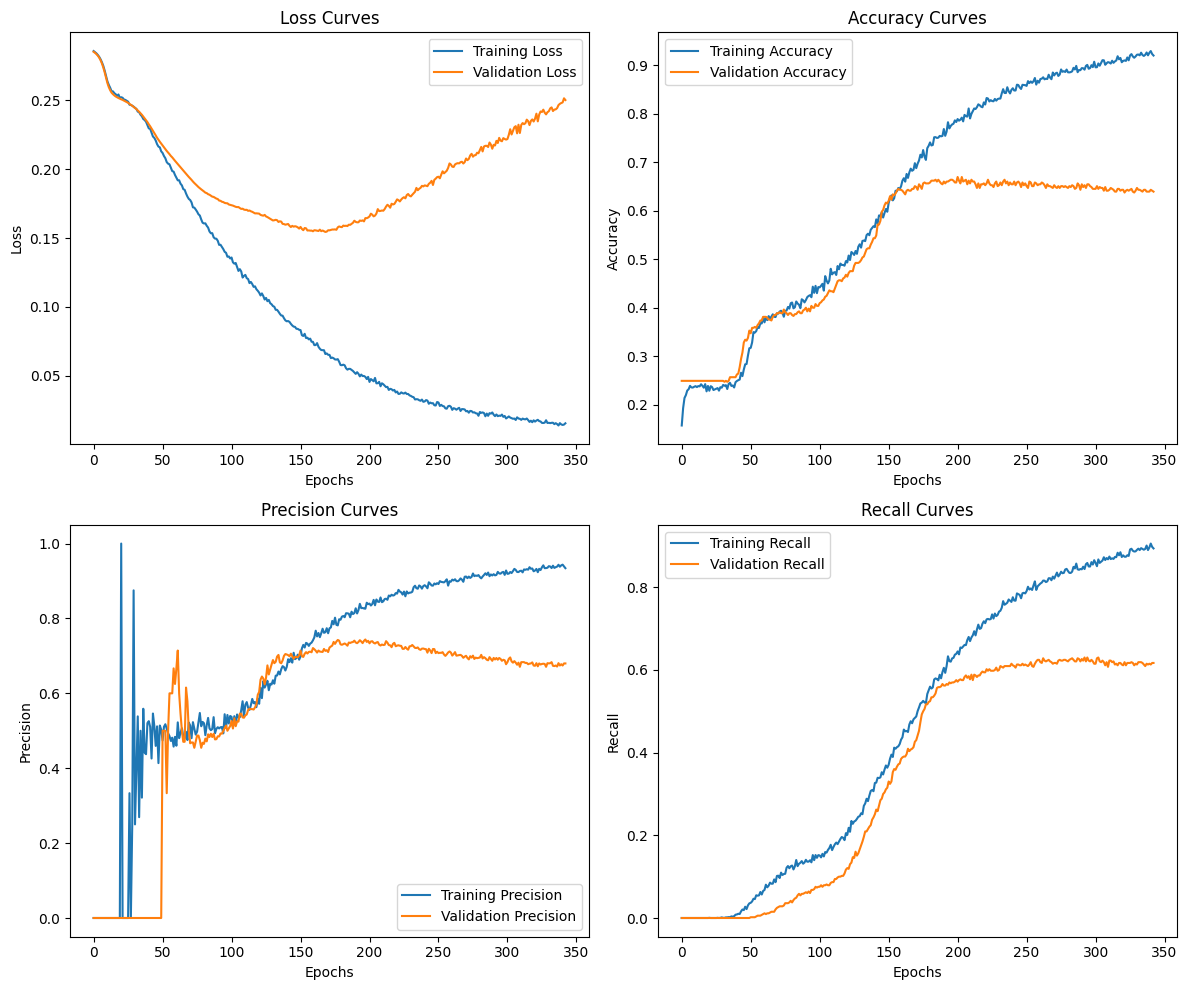

In [32]:
# Plot training and validation loss, accuracy, precision, and recall curves
history = model.history.history
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(history['Precision'], label='Training Precision')
plt.plot(history['val_Precision'], label='Validation Precision')
plt.title('Precision Curves')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(history['Recall'], label='Training Recall')
plt.plot(history['val_Recall'], label='Validation Recall')
plt.title('Recall Curves')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
# Check the model's predictions on the validation set with missing department values
y_val_pred = model.predict(X_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
print("Predicted Departments for Validation Set:")
print(y_val_pred_classes)

# Print out a few of the original complaints with missing department values alongside their predicted department to see if the predictions make sense
for i in range(5):
    print(f"Original Complaint: {complaints_df.loc[null_dept_indices[i], 'Complaint Description']}")
    print(f"Predicted Department: {np.unique(processed_complaints_df['Department'].dropna())[y_val_pred_classes[i]]}")
    print("-" * 50)
    

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Predicted Departments for Validation Set:
[4 1 0 0 5 6 2 2 2 0 3 2 1 5 0 1 0 0 0 0 0 1 2 3 2 0 3 0 2 0 0 0 0 0 2 0 0
 0 2 0 2 3 2 3 1 2 1 0 6 0 0 2 2 2 0 0 2 0 0 1 5 0 2 2 0 0 4 5 2 4 2 0 0 2
 0 2 0 0 2 4 4 1 0 2 3 2 2 2 2 2 5 0 1 0 1 0 0 4 3 0 0 1 0 2 1 1 0 2 0 0 3
 2 1 0 1 1 0 0 2 0 1 0 3 1 0 2 0 0 4 4 0 0 0 0 2 2 0 0 2 3 2 0 0 0 0 3 6 1
 2 2 0 0 0 2 1 2 2 1 3 1 2 0 1 5 3 2 4 1 1 2 2 1 2 1 0 2 3 1 5 2 3 5 3 1 3
 2 1 2 3 3 2 2 1 1 3 2 3 2 1 2 1 5 3 3 1 0 1 3 2 4 1 1 5 1 0 1 1 2 5 5 3 3
 0 1 0 3 2 2 4 4 2 5 3 1 2 3 5 1 3 0 3 3 3 3 1 2 5 4 0 1 4 1 0 1 2 2 1 2 1
 0 1 0 2 2 1 4 2 2 1 2 3 3 5 1 3 2 3 1 3 4 0 1 1 2 1 2 3 5 1 0 1 3 2 3 2 1
 1 5 2 2 1 2 0 1 1 1 5 5 1 5 1 1 1 3 2 4 1 1 6 1 4 2 0 1 0 2 2 1 2 1 3 2 3
 4 5 5 3 1 0 2 3 3 5 2 1 1 1 4 3 5 1 1 1 0 3 0 3 2 1 2 5 1 2 2 2 1 1 1 1 5
 0 0 0 4 0 2 1 0 1 1 1 5 4 4]
Original Complaint: On XX/XX/XX22 I found out that my account was frozen for no apparent reason. I went to the BOA branch in XXXX XXXX NY,

In [34]:
# Create the sentiment analyzer and add it as a new column in a new dataframe to avoid messing with the original
anal_sent = SentimentIntensityAnalyzer()
sentiment_complaints_df = processed_complaints_df.copy()

sentiment_complaints_df['Sentiment Score'] = sentiment_complaints_df['Complaint Description'].apply(lambda x: anal_sent.polarity_scores(x)['compound'])
print(sentiment_complaints_df[['Complaint Description', 'Sentiment Score']].head())


                               Complaint Description  Sentiment Score
0  xxxxxx<NUM><NUM> opened safe balance account o...          -0.8720
1  item bank abc credit report belong must remove...           0.4588
2  xxxxxx<NUM><NUM> found account frozen apparent...           0.0000
3  so last time phone b prepaid regarding edd acc...           0.7096
4  got <NUM> hard inquiry dont recognize xxxx xxx...          -0.1027


In [35]:
# Do sentiment analysis on the orignal complaints w/o preprocessing and compare the scores to the preprocessed ones to see if there is a significant difference
original_sentiment_complaints_df = dept_filled_complaints_df.reset_index().copy()
original_sentiment_complaints_df['Sentiment Score'] = original_sentiment_complaints_df['Complaint Description'].apply(lambda x: anal_sent.polarity_scores(x)['compound'])
print(original_sentiment_complaints_df[['Complaint Description', 'Sentiment Score']].head())


                               Complaint Description  Sentiment Score
0  on XX/XX/XX22 I opened a safe balance account ...          -0.9488
1  There is an item from Bank of ABC on my credit...          -0.1207
2  On XX/XX/XX22 I found out that my account was ...          -0.5267
3  So, last time I was on the phone with b of a p...           0.1901
4  Got 5 hard inquiries I dont recognize, from XX...          -0.1027


In [36]:
# print the full text of each complaint in the head() of the original and preprocessed sentiment dataframes to
# compare the changes made by preprocessing and see if there is a significant difference in the sentiment scores.
# Skip entries missing an index
for i in range(10):
    if i not in original_sentiment_complaints_df.index or i not in sentiment_complaints_df.index:
        continue
    print(f"Original Complaint: {original_sentiment_complaints_df.loc[i]['Complaint Description']}")
    print(f"Original Sentiment Score: {original_sentiment_complaints_df.loc[i]['Sentiment Score']}")
    print(f"Preprocessed Complaint: {sentiment_complaints_df.loc[i]['Complaint Description']}")
    print(f"Preprocessed Sentiment Score: {sentiment_complaints_df.loc[i]['Sentiment Score']}")
    print("-" * 50)


Original Complaint: on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked contact customer service @ XXXX '' error message. I placed the call and was told I would have to go to a branch to verify my identity, which I did. At the same time, I was told I had a positive balance of of {$650.00} and could make a withdrawal from the teller, which I did for {$400.00} leaving a balance of + {$250.00}. Shortly after that, I deposited a mobile check for {$5XX.00}. On XX/XX/XX22, again I attempted to login and received the previous error message along with 3 emails stating a hold was placed on my account. Contacting the same previous number I was told that my acct was being closed by the Risk Dept. due to lack of identity verification, which I told them I had done the day before. I was then told it didn't matter the account was already being closed and it was

## Final Results:
### Model performance
- With the preprocessing and EDA I was able to get the data to recall at about .66-.72.
- I focused on recall due to the data being fairly imbalanced among multiple classes, and since it focuses on True Positives, it was a better metric to use than accuracy or precision
- I originally used class weights to help offset some of the imbalance as well but my results were not very stable and varied a lot with mild tuning changes. 
    - I ended up using AdamW optimizer and Categorical Focal Crossentropy loss function which seemed to help the stability and overall performance of the model
    - Some more tuning could be used to get the model to perform better, but I wanted to continue with the rest of the project and not focuse too much on a perfect performance
    - I can make changes after the rest of the project is done to try and improve the performance
### Sentiment Analysis
- The sentiment scores were mostly negative, which is expected since these are complaints.
- I also tried to compare the preprocessed complaints against the originals and was surprised to see that the complaints in their original form seemed to align better with how I would have read the sentiments as a human.
- I had read that a lot of these sentiment analyzers were actually pretty good at handling things like stop words and punctuation, as it can add a lot of context to the sentiment.
- I left both forms in the notebook so they can be looked over to see if I missed something, but I think the original complaints might actually be more useful for sentiment analysis than the preprocessed ones.
### Business insights
- Sentiment scores can be useful to see which customers are the most upset with the bank and what priority they can be sorted into.
    - That is a fairly basic take, but I think it is worth mentioning
- Another idea that the metrics along with complaints can be used for is the possibility to identify customers who are maybe not totally dissatisfied, or even ambivalent towards the bank and try to sell them on some of the bank's other products that might fit their needs better
    - Like a different bank account type, or a credit card with better rewards for the things they spend the most money on
- The department predictions can be used to help route the complaints to the right department faster, which can help speed up the resolution process and make customers happier
- If you are now measuring sentiment you can put a number to the average sentiment increase or decrease that happens when changes are made to a department's processes or products
